In [1]:
# 4.1 Import Library & Konfigurasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             f1_score, accuracy_score, confusion_matrix,
                             classification_report, precision_score, recall_score)

# Konfigurasi Visualisasi
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['font.size'] = 12

# Path File (DISESUAIKAN UNTUK VTB)
MODEL_FILE = '../../../stemming/outputs/VTB/sentiment_clean.csv' 
GT_FILE = '../../../stemming/outputs/evaluation/ground_truth_final.csv'
OUTPUT_DIR = '../../../stemming/outputs/evaluation'

print(f"[INFO] Library dimuat. Konfigurasi evaluasi VTB siap.")

[INFO] Library dimuat. Konfigurasi evaluasi VTB siap.


In [2]:
# 4.2 Load dan Merge Data
# Load Ground Truth dan Hasil Model VTB
df_gt = pd.read_csv(GT_FILE)
df_model = pd.read_csv(MODEL_FILE)

# Merge berdasarkan ID 'no'
df_eval = pd.merge(
    df_gt[['no', 'ground_truth_scaled']],
    df_model[['no', 'compound_score']],
    on='no',
    how='inner'
).dropna()

print(f"[INFO] Dataset evaluasi VTB berhasil digabung: {len(df_eval)} data.")
print(f"   - Range VADER VTB (Compound): {df_eval['compound_score'].min():.4f} s.d {df_eval['compound_score'].max():.4f}")
print(f"   - Range Human (Scaled):       {df_eval['ground_truth_scaled'].min():.4f} s.d {df_eval['ground_truth_scaled'].max():.4f}")

[INFO] Dataset evaluasi VTB berhasil digabung: 450 data.
   - Range VADER VTB (Compound): -0.9648 s.d 0.9310
   - Range Human (Scaled):       -1.0000 s.d 0.4000


In [3]:
# 4.3 Skala Evaluasi
# Skala visual untuk scatter plot (opsional jika ingin sumbu Y tetap -4 s.d 4)
df_eval['human_visual_score'] = df_eval['ground_truth_scaled'] * 4

y_true_scaled = df_eval['ground_truth_scaled']
y_pred_scaled = df_eval['compound_score']

y_human_visual = df_eval['human_visual_score']
y_model_pred = df_eval['compound_score']

print("[INFO] Persiapan metrik evaluasi selesai.")

[INFO] Persiapan metrik evaluasi selesai.


In [4]:
# 4.4 Hitung Pearson dan Spearman (Linear dan Monotonic Relationship)
# Hitung Pearson dan Spearman
pearson_r, p_val = pearsonr(y_true_scaled, y_pred_scaled)
spearman_rho, p_val_s = spearmanr(y_true_scaled, y_pred_scaled)

# Hitung Error Metrics
rmse = np.sqrt(mean_squared_error(y_true_scaled, y_pred_scaled))
mae = mean_absolute_error(y_true_scaled, y_pred_scaled)
r2 = np.corrcoef(y_true_scaled, y_pred_scaled)[0, 1]**2 

print("=== HASIL EVALUASI CONTINUOUS SCORE (VTB) ===")
print(f"Pearson Correlation (r)    : {pearson_r:.4f}")
print(f"Spearman Rank (rho)        : {spearman_rho:.4f}")
print(f"RMSE (Root Mean Sq. Error) : {rmse:.4f}")
print(f"MAE (Mean Abs. Error)      : {mae:.4f}")
print(f"R-Squared (R²)             : {r2:.4f}")

=== HASIL EVALUASI CONTINUOUS SCORE (VTB) ===
Pearson Correlation (r)    : 0.2158
Spearman Rank (rho)        : 0.1925
RMSE (Root Mean Sq. Error) : 0.5155
MAE (Mean Abs. Error)      : 0.3736
R-Squared (R²)             : 0.0466


In [5]:
# 4.5 Evaluasi Kategorikal dengan Threshold ±0.05
# Fungsi kategorisasi berdasarkan threshold standar ±0.05
def categorize(score):
    if score > 0.05: return 'positive'
    elif score < -0.05: return 'negative'
    else: return 'neutral'

df_eval['pred_class'] = df_eval['compound_score'].apply(categorize)
df_eval['gt_class'] = df_eval['ground_truth_scaled'].apply(categorize)

labels = ['negative', 'neutral', 'positive']

# Hitung Metrik Klasifikasi
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
f1_macro = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', labels=labels)

print("HASIL EVALUASI KLASIFIKASI (VTB)")
print(f"Accuracy        : {acc:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print("-" * 50)
print("Classification Report VTB:")
print(classification_report(df_eval['gt_class'], df_eval['pred_class'], target_names=labels, zero_division=0))

HASIL EVALUASI KLASIFIKASI (VTB)
Accuracy        : 0.4378
F1-Score (Macro): 0.4348
--------------------------------------------------
Classification Report VTB:
              precision    recall  f1-score   support

    negative       0.44      0.48      0.46       153
     neutral       0.57      0.30      0.40       164
    positive       0.38      0.56      0.45       133

    accuracy                           0.44       450
   macro avg       0.46      0.45      0.43       450
weighted avg       0.47      0.44      0.43       450



In [6]:
# 4.6 Tabel Metrik Utama
acc = accuracy_score(df_eval['gt_class'], df_eval['pred_class'])
prec = precision_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
rec = recall_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
f1 = f1_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)

metrics_df = pd.DataFrame([{
    'Konfigurasi': 'VTB',
    'Accuracy': f"{acc:.4f}",
    'Precision (M)': f"{prec:.4f}",
    'Recall (M)': f"{rec:.4f}",
    'F1-Score (M)': f"{f1:.4f}"
}])

metrics_df

,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M)
0,VTB,0.4378,0.4621,0.4461,0.4348


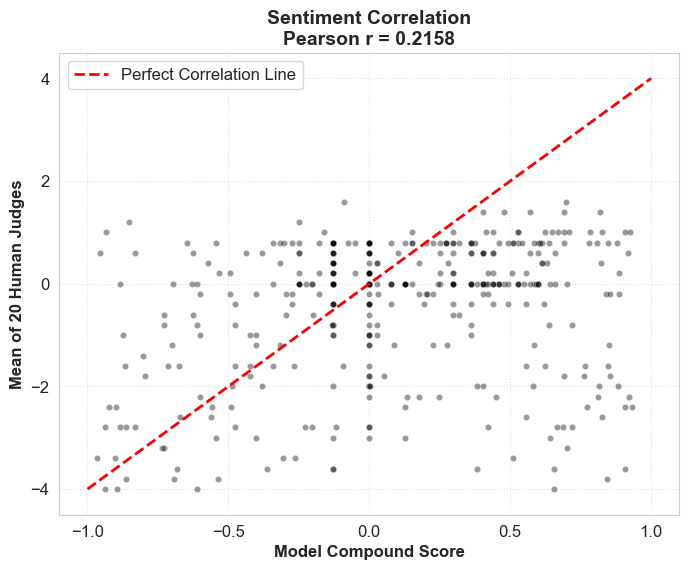

[INFO] Scatter plot tersimpan.


In [7]:
# 4.7 Visualisasi: Scatter Plot dan Regression Line
plt.figure(figsize=(8, 6))

# Scatter Plot: X = Model (-1,1), Y = Human (-4,4)
sns.scatterplot(x=y_model_pred, y=y_human_visual, alpha=0.4, color='black', s=20)

# Garis Merah: Garis regresi ideal (y = x * 4)
x_vals = np.linspace(-1, 1, 100)
y_vals = x_vals * 4
plt.plot(x_vals, y_vals, color='red', linestyle='--', linewidth=2, label='Perfect Correlation Line')

# Konfigurasi Sumbu
plt.xlim(-1.1, 1.1)
plt.ylim(-4.5, 4.5)
plt.xticks(np.arange(-1, 1.1, 0.5))
plt.yticks(np.arange(-4, 5, 2))

plt.xlabel('Model Compound Score', fontsize=12, fontweight='bold')
plt.ylabel('Mean of 20 Human Judges', fontsize=12, fontweight='bold')
plt.title(f'Sentiment Correlation\nPearson r = {pearson_r:.4f}', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(f'{OUTPUT_DIR}/scatter_plot_VTB.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Scatter plot tersimpan.")

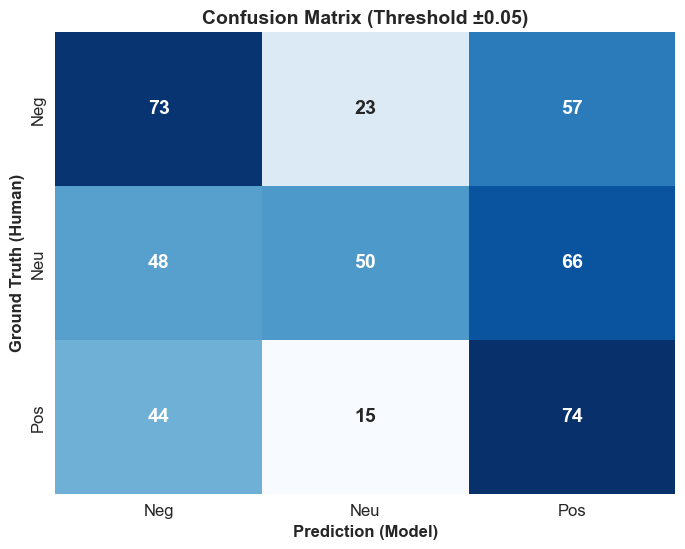

[INFO] Confusion matrix tersimpan.
[INFO] Proses evaluasi selesai!


In [8]:
# 4.8 Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))

# Hitung Confusion Matrix
cm = confusion_matrix(df_eval['gt_class'], df_eval['pred_class'], labels=labels)

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Neg', 'Neu', 'Pos'], 
            yticklabels=['Neg', 'Neu', 'Pos'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Confusion Matrix (Threshold ±0.05)', fontsize=14, fontweight='bold')
plt.ylabel('Ground Truth (Human)', fontsize=12, fontweight='bold')
plt.xlabel('Prediction (Model)', fontsize=12, fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/confusion_matrix_VTB.png', dpi=300, bbox_inches='tight')
plt.show()

print("[INFO] Confusion matrix tersimpan.")
print("[INFO] Proses evaluasi selesai!")

In [9]:
# 4.9 Menyimpan Hasil
prec = precision_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)
rec = recall_score(df_eval['gt_class'], df_eval['pred_class'], average='macro', zero_division=0)

metrics_df = pd.DataFrame([{
    'Konfigurasi': 'VTB (Translation Based)',
    'Accuracy': f"{acc:.4f}",
    'Precision (M)': f"{prec:.4f}",
    'Recall (M)': f"{rec:.4f}",
    'F1-Score (M)': f"{f1_macro:.4f}",
    'Pearson-r': f"{pearson_r:.4f}"
}])

# Simpan ke CSV
metrics_df.to_csv(os.path.join(OUTPUT_DIR, 'evaluation_metrics_VTB.csv'), index=False)

# Simpan JSON Summary
eval_summary = {
    'konfigurasi': 'VTB (Translation Based)',
    'dataset_size': len(df_eval),
    'metrics': metrics_df.iloc[0].to_dict()
}
with open(os.path.join(OUTPUT_DIR, 'evaluation_summary_VTB.json'), 'w') as f:
    json.dump(eval_summary, f, indent=2)

print("\n[INFO] Evaluasi VTB Selesai. Data metrik telah disimpan.")
metrics_df


[INFO] Evaluasi VTB Selesai. Data metrik telah disimpan.


,Konfigurasi,Accuracy,Precision (M),Recall (M),F1-Score (M),Pearson-r
0,VTB (Translation Based),0.4378,0.4621,0.4461,0.4348,0.2158
